# NBA Shot Decision Optimizer: XGBoost Model Training & Evaluation

In this notebook, we train an **XGBoost Model** to predict the probability of a shot being made ($P(	ext{Make})$).

The evaluation process mirrors the one used for logistic regression to ensure a fair comparison, with additional advanced visualizations.

### Table of Contents
1.  **Setup & Data Loading**: Importing utils and loading the dataset.
2.  **Preprocessing**: Cleaning and splitting into Train/Val/Test sets.
3.  **Model Pipeline**: Building the XGBoost pipeline.
4.  **Training**: Early stopping to prevent overfitting.
5.  **Optional: Hyperparameter Tuning**: Randomized search for best params.
6.  **Standard Evaluation**: Accuracy, ROC-AUC, and Log-Loss.
7.  **Advanced Visualizations**: Feature Importance (SHAP) and ROC Curves.
8.  **Advanced Evaluation (xPts)**: Aggregation at the Game Level.
9.  **Calibration**: Reliability Diagram (xPts vs Actual).
10. **Shot Quality Insights**: Expected Points by Distance.
11. **Conclusion**: Final report and performance summary.

In [1]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import joblib
import seaborn as sns
import shap
from sklearn.metrics import roc_auc_score, accuracy_score

# Add root directory to path to allow importing 'utils'
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import our custom XGBoost modules
from utils import xg_boost_modeling_utils as xgb_utils

# Pandas settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 1. Load Data
We load the dataset created in the previous step (`feature_engineering`). This dataset already contains all calculated metrics like `PLAYER_ZONE_FG_PCT`, `SHOTCLOCK`, and `OPP_DEF_STRENGTH`.

In [2]:
INPUT_FILE = '../data/processed/nba_processed_shot_data.parquet'

print(f"Loading data from: {INPUT_FILE} ...")
if not os.path.exists(INPUT_FILE):
    print(f"Error: File not found: {INPUT_FILE}")
else:
    df = pd.read_parquet(INPUT_FILE)
    print(f"Dataset loaded: {len(df):,} shots across {df['SEASON'].nunique()} seasons.")
    print(f"Class balance: {df['SHOT_MADE_FLAG'].value_counts(normalize=True)}")

Loading data from: ../data/processed/nba_processed_shot_data.parquet ...
Dataset loaded: 1,293,360 shots across 7 seasons.
Class balance: SHOT_MADE_FLAG
0    0.532392
1    0.467608
Name: proportion, dtype: float64


## 2. Preprocessing & Split
Before training, we need to prepare the data carefully to ensure the model learns valid patterns, not noise or "cheats."

1.  **Cleaning & Feature Selection:** We remove specific columns for three main reasons:
    * **Generalization (Metadata):** We drop `GAME_ID`, `PLAYER_NAME`, and `TEAM_NAME`. The model should learn **what** constitutes a good shot (e.g., "Open Corner 3"), not memorize that Stephen Curry is a good shooter. (We use his stats, like `PLAYER_ZONE_FG_PCT`, to capture his skill instead).
    * **Data Leakage:** We must remove columns like `EVENT_TYPE` (which contains text like "Missed Shot"). If we left this in, the model would simply read the answer instead of predicting it.
    * **Redundancy:** We remove raw coordinates like `LOC_X` and `LOC_Y` because we have already converted them into better features: `SHOT_DISTANCE` and `SHOT_ANGLE`.

2.  **Chronological Split:** We must not split the data randomly. To simulate the real world, we train on the **Past** (Seasons up to 2024) and test on the **Future** (Season 2024-25).

In [3]:
df_model = xgb_utils.clean_data_for_training(df)
print(f"\nFeatures for model: {len(df_model.columns)} columns")
print(f"Sample features: {df_model.columns[:10].tolist()}...")

# Split into Train, Validation, and Test
VALIDATION_SEASON = '2023-24'  # Used for early stopping
TEST_SEASON = '2024-25'  # Final evaluation

print(f"\nSplitting data into Train/Validation/Test sets...")
X_train, y_train, X_val, y_val, X_test, y_test = xgb_utils.split_data_by_season(
    df_model, 
    split_season=TEST_SEASON,
    validation_season=VALIDATION_SEASON
)

print(f"\nTraining Size:   {len(X_train):,} shots")
print(f"Validation Size: {len(X_val):,} shots (Season {VALIDATION_SEASON})")
print(f"Test Size:       {len(X_test):,} shots (Season {TEST_SEASON})")

# Calculate class weights for potential imbalance handling
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio (neg/pos): {pos_weight:.2f}")


Features for model: 18 columns
Sample features: ['PERIOD', 'ACTION_TYPE', 'SHOT_DISTANCE', 'SHOT_MADE_FLAG', 'GAME_DATE', 'SEASON', 'CUSTOM_SHOT_ZONE', 'SHOT_ANGLE', 'SHOT_VALUE', 'TIME_REMAINING']...

Splitting data into Train/Validation/Test sets...
Splitting data. Test Season: 2024-25
Validation Season: 2023-24
Train Set Seasons: ['2019-20', '2020-21', '2021-22', '2022-23'] (813,041 shots)
Val Set Seasons:   ['2023-24'] (218,700 shots)
Test Set Seasons:  ['2024-25', '2025-26'] (261,619 shots)

Training Size:   813,041 shots
Validation Size: 218,700 shots (Season 2023-24)
Test Size:       261,619 shots (Season 2024-25)

Class imbalance ratio (neg/pos): 1.15


## 3. Model Pipeline

We use **XGBoost** with improved defaults and **early stopping** to prevent overfitting.
The pipeline structure remains consistent for reproducibility.


Since we have a mix of numerical (e.g., Distance) and categorical (e.g., Position) data, we build a pipeline:

* **Numerical Features:**
    * Values are normalized (StandardScaler).
* **Categorical Features:**
    * **One-Hot Encoding:** Text values (e.g., "Guard") are converted into binary columns (0/1).

In [4]:
# Automatic detection of column types
num_feats, cat_feats = xgb_utils.get_feature_lists(X_train)

print(f"\nFeature Types:")
print(f"  Numerical:   {len(num_feats)} features")
print(f"  Categorical: {len(cat_feats)} features")

# Build XGBoost Pipeline with improved parameters
# Optionally adjust scale_pos_weight for class imbalance
xgb_params = {
    'scale_pos_weight': pos_weight if pos_weight > 1.5 else 1.0,
    'n_estimators': 1000  # Will use early stopping in training function
}

model_pipeline = xgb_utils.build_xgboost_pipeline(num_feats, cat_feats, xgb_params)

print(f"Scale pos weight: {xgb_params['scale_pos_weight']:.2f}")


Feature Types:
  Numerical:   12 features
  Categorical: 3 features
Scale pos weight: 1.00


## 4. Training with Early Stopping
We use the validation set to monitor performance and stop training when the model stops improving.

In [5]:
print("\n" + "="*60)
print("TRAINING XGBOOST MODEL")
print("="*60)

# Use the helper function to train with early stopping
model_pipeline = xgb_utils.fit_pipeline_with_early_stopping(
    model_pipeline,
    X_train,
    y_train,
    X_val,
    y_val,
    verbose=False
)

print(f"\nTraining complete.")


TRAINING XGBOOST MODEL
Fitting preprocessor on training data...
Training XGBoost with early stopping (patience=50)...


/Users/melihkoc/Desktop/HM/7.Semester/shot-decision-optimizer/.venv/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [20:25:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Early stopping triggered at iteration 470 (out of 1000 max)

Training complete.


## 5. Optional: Hyperparameter Tuning

If you want to squeeze out additional performance, you can run randomized search.

**Important**: If you run this cell, the resulting `tuned_model` will overwrite the original `model_pipeline` and its predictions (`y_prob_test`, `y_pred_test`) will be used for all subsequent evaluation steps in this notebook.

### Hyperparameter Space & Metrics Explanation

**1. Scoring Metric: ROC-AUC**
We currently use **ROC-AUC** (`roc_auc`) as the primary metric for tuning. 
- **Why?** It is robust to class imbalance (makes vs misses) and measures the model's ability to rank higher quality shots above lower quality ones.
- **Alternative:** **Log Loss** (`neg_log_loss`) is also valuable as it penalizes confident wrong predictions and encourages well-calibrated probabilities. Since we calculate **Expected Points (xPts)**, calibration is crucial. We use ROC-AUC for structural tuning and rely on the *Calibration Curve* (Section 10) to verify probability reliability.

**2. Parameter Search Space**
We search over the following grid to balance model complexity and regularization:

| Parameter | Range | Reasoning |
|-----------|-------|-----------|
| `max_depth` | `[4, 5, 6, 7, 8]` | Controls tree complexity. Shallow trees (4) prevent overfitting, while deeper trees (8) capture complex spatial interactions. |
| `min_child_weight` | `[1, 3, 5, 7]` | Minimum sum of instance weight (hessian) needed in a child. Higher values prevent the model from learning relations specific to only a few samples (noise). |
| `learning_rate` | `[0.01, 0.05, 0.1]` | Step size shrinkage. Lower values (0.01) generally generalize better but require more trees. |
| `subsample` | `[0.7, 0.8, 0.9]` | Fraction of training instances used for each tree. Subsampling prevents overfitting. |
| `colsample_bytree` | `[0.7, 0.8, 0.9]` | Fraction of columns (features) used for each tree. Similar to Random Forest's feature selection. |
| `gamma` | `[0, 0.1, 0.2]` | Minimum loss reduction required to make a further partition. Acts as a regularization parameter. |
| `reg_alpha` (L1) | `[0, 0.1, 0.5]` | L1 regularization on weights. Encourages sparsity (feature selection). |
| `reg_lambda` (L2) | `[0.5, 1.0, 2.0]` | L2 regularization on weights. Prevents large weights and stabilizes the model. |

In [6]:
# Set to True to run the tuning
ENABLE_TUNING = True

if ENABLE_TUNING:
    print("\n" + "="*60)
    print("HYPERPARAMETER TUNING (Optional)")
    print("="*60)

    tuned_model = xgb_utils.tune_xgboost_hyperparameters(
        model_pipeline, 
        X_train, 
        y_train,
        n_iter=10,  # Increase for more thorough search
        cv=3,
        scoring='roc_auc'
    )

    # Re-evaluate with tuned model and overwrite the main variables
    print("\nRe-evaluating with tuned model...")
    y_prob_test, y_pred_test = xgb_utils.evaluate_model_metrics(
        tuned_model, X_test, y_test)

    # Overwrite the main pipeline with the tuned one for subsequent cells
    model_pipeline = tuned_model

else:
    print("\nSkipping hyperparameter tuning. Set ENABLE_TUNING = True to run.")
    # Ensure test predictions exist even if tuning is skipped
    print("\nGenerating predictions with default model...")
    y_prob_test, y_pred_test = xgb_utils.evaluate_model_metrics(
        model_pipeline, X_test, y_test)


# Save Model
MODELS_DIR = '../models'
MODEL_NAME = 'nba_xgboost_model.joblib'
SAVE_PATH = os.path.join(MODELS_DIR, MODEL_NAME)

joblib.dump(model_pipeline, SAVE_PATH)
print(f"Model saved successfully at: {SAVE_PATH}")


HYPERPARAMETER TUNING (Optional)

Starting RandomizedSearchCV with 10 iterations and 3-fold CV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/Users/melihkoc/Desktop/HM/7.Semester/shot-decision-optimizer/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:27:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/melihkoc/Desktop/HM/7.Semester/shot-decision-optimizer/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:27:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/melihkoc/Desktop/HM/7.Semester/shot-decision-optimizer/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:27:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/melihkoc/Desktop/HM/7.Semester/shot-decision-optimizer/.venv/lib/python3.12


Best roc_auc: 0.6696
Best parameters:
  classifier__subsample: 0.9
  classifier__reg_lambda: 2.0
  classifier__reg_alpha: 0.1
  classifier__min_child_weight: 7
  classifier__max_depth: 8
  classifier__learning_rate: 0.01
  classifier__gamma: 0
  classifier__early_stopping_rounds: None
  classifier__colsample_bytree: 0.8

Re-evaluating with tuned model...

STANDARD MODEL METRICS
Log Loss: 0.6339
Accuracy: 0.6337
ROC-AUC:  0.6653

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.85      0.71    139332
           1       0.69      0.39      0.50    122287

    accuracy                           0.63    261619
   macro avg       0.65      0.62      0.61    261619
weighted avg       0.65      0.63      0.61    261619

Model saved successfully at: ../models/nba_xgboost_model.joblib


## 6. Standard Evaluation


Here we check classic Machine Learning metrics:
* **Accuracy:** How often is the model correct (Make or Miss)?
* **ROC-AUC:** How well can the model distinguish between sure makes and sure misses? (0.5 = Guessing, 1.0 = Perfect).
* **Log-Loss:** The primary metric for probability quality. It measures the "cost" of being wrong by penalizing confident errors heavily (e.g., if the model predicts a 90% chance of a make, but it misses, the penalty is high). Lower is better.

In [7]:
y_prob_val, y_pred_val = xgb_utils.evaluate_model_metrics(model_pipeline, X_val, y_val)


STANDARD MODEL METRICS


Log Loss: 0.6326
Accuracy: 0.6326
ROC-AUC:  0.6686

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.84      0.71    114961
           1       0.69      0.40      0.51    103739

    accuracy                           0.63    218700
   macro avg       0.65      0.62      0.61    218700
weighted avg       0.65      0.63      0.61    218700



#### **Takeaways from the metrics:**

**1. Log Loss (0.6326) – *Precision in Probability***

* **What it measures:** The "certainty" of the model's predictions. It penalizes the model more heavily if it is confidently wrong about a shot's outcome.
* **Verdict:** A Log Loss of **0.6326** is solid for public NBA data. Because basketball involves significant "noise" where even a perfect look can rim out; A stable, low Log Loss ensures that our **Expected Points (xPts)** model remains calibrated and trustworthy.

**2. Accuracy (63.26%) – *Navigating the Variance***

* **What it measures:** The percentage of total shots where the model correctly guessed "Make" or "Miss".
* **Verdict:** Achieving **~63%** is a strong benchmark in sports analytics.
    * **The "Contested Make" Factor:** In the NBA, elite shooters often hit "bad" shots (e.g., a fadeaway with a hand in the face). The model correctly identifies these as low-probability events ( P(Make) is low), but if the shot goes in, the "Accuracy" takes a hit.
    * For an **Optimizer**, we actually want this: we want the model to tell us it was a *low quality decision*, regardless of the lucky outcome.



**3. ROC-AUC (0.6686) – *Shot Quality Discrimination***

* **What it measures:** The model’s ability to distinguish between a high-efficiency "Easy Look" and a low-efficiency "Tough Look".
* **Verdict:** A score of **0.6686** indicates a solid discriminative power. It proves the model is not just guessing; it successfully ranks a wide-open corner three or a layup significantly higher than a contested mid-range jumper. This is the "brain" of our shot-selection optimizer.


**Summary:**

The model shows a "Conservative Bias," evidenced by the **Recall of 0.40** for makes. It only predicts a "Make" when the spatial and situational data overwhelmingly suggest a high-quality look. For a coaching tool, this is ideal: it prioritizes **reproducible shot quality** over high-variance "hero ball," ensuring the system rewards the best possible basketball decisions.

## 7. Advanced Visualizations: Feature Importance

Understanding which features drive the model's predictions is critical for interpretability.

### 7.1 Global Feature Influence (Magnitude & Direction)


Short explanation of SHAP values

> **SHAP values explain how much each feature contributes to a prediction relative to the model’s average output** Positive SHAP values increase the predicted probability of a made shot, while negative values decrease it.

Computing SHAP values (this may take a minute)...


  0%|          | 0/1000 [00:00<?, ?it/s]

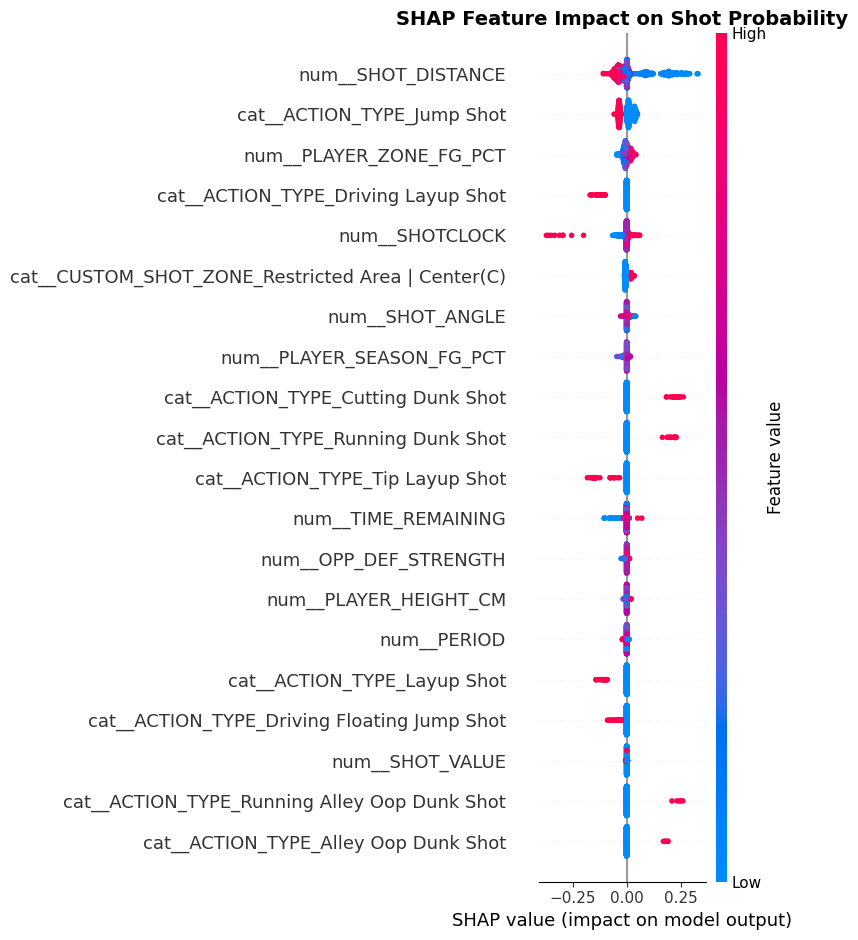

In [8]:
xgb_utils.plot_shap_summary(model_pipeline, X_test)

**Key insights from the SHAP Beeswarm Plot:**

1. **Shot Distance dominates (`SHOT_DISTANCE`):**  
   Higher shot distances consistently push predictions towards a miss. The wide spread and strong negative SHAP values confirm that distance is the most influential physical factor affecting shot success.

2. **Shot Type matters (`ACTION_TYPE_*`):**  
   Close range actions such as layups and dunks show positive SHAP values, while jump shots tend to reduce make probability. This reflects the fundamental efficiency differences between shot types.

3. **Contextual skill over raw talent (`PLAYER_ZONE_FG_PCT` vs. `PLAYER_SEASON_FG_PCT`):**  
   Zone specific shooting percentages have a stronger and more consistent positive impact than overall season FG%. The model values *where* a player is effective, not just *how good* they are in general.

4. **Time pressure hurts efficiency (`SHOTCLOCK`, `TIME_REMAINING`):**  
   Lower shot clock values and late game situations shift predictions negatively. Rushed or end of clock shots are inherently harder to convert.

5. **Game dynamics and physical traits play a secondary role:**  
   Features such as defender strength, player height, and game period show smaller effects, indicating that physical and situational context refines but does not override shot quality.

**Summary:**

The feature importance distribution validates that the model has internalised the **efficiency hierarchy** of basketball: At the rim actions > Shot Distance > Shot Type. 

For our shot optimizer, this is important, because it ensures that recommendations are grounded in high probability basketball logic, prioritizing good areas and high momentum actions rather than low efficiency perimeter isolation.

-----
### 7.2 SHAP Dependence Plot Interpretation (Shot Distance)

The SHAP dependence plot visualizes how **shot distance**, as processed by the model, influences the predicted probability of a made shot in a binary classification setting.

- **X-axis (Feature value):**  
  The shot distance after preprocessing, i.e. the *standardized* distance used internally by the model. A value of `0` corresponds to an average shot distance, negative values indicate shots taken closer than average, and positive values indicate shots taken farther than average. The scale therefore reflects *relative distance*, not physical units (e.g. meters/feet).

- **Y-axis (SHAP value):**  
  The SHAP value represents the marginal contribution of shot distance to the predicted make probability for each individual shot. Positive SHAP values increase the predicted probability of a made shot relative to the model’s baseline prediction, while negative values decrease it. Since the model is explained on the probability scale (log-odds), SHAP values can be interpreted approximately as changes in predicted probability.


Computing SHAP values for dependence plot (this may take a minute for 500 samples)...


  0%|          | 0/500 [00:00<?, ?it/s]

<Figure size 1400x1000 with 0 Axes>

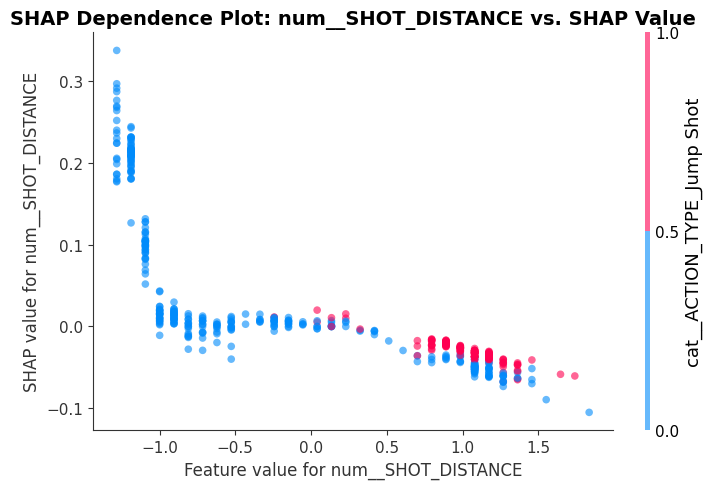

In [9]:
xgb_utils.plot_shap_dependence(model_pipeline, X_test, 'num__SHOT_DISTANCE', sample_size=500)

#### Observed patterns and interpretation
1. **Strong non-linear effect near the basket**  
   For very small (below-average) distances, SHAP values are strongly positive, indicating that shots taken close to the rim substantially increase the predicted probability of a make. This captures the well-known “rim advantage” and shows that the model has learned a highly non-linear efficiency gain at short distances rather than a simple linear relationship.

2. **Mid-range plateau (low marginal effect of distance)**  
   In the intermediate distance range, SHAP values cluster around zero, suggesting that shot distance provides little additional marginal information to the model in this region. This does not imply that these shots are easy or efficient, but rather that conditional on other features already in the model; small changes in distance within this range do not meaningfully alter the prediction. Other variables likely dominate the model’s decision here.

3. **Negative contribution at long distances**  
   At large positive standardized distances, SHAP values become increasingly negative. This indicates that long-range shots systematically reduce the predicted probability of a make, reflecting the decreasing shooting efficiency at greater distances. The smooth decline highlights that the model has learned a gradual, distance-dependent penalty rather than a hard cutoff.

4. **Interaction structure (coloring by interaction feature)**  
   The color gradient reveals interaction effects between shot distance and the shot type. Differences in SHAP values at the same distance but different colors indicate that the impact of distance is conditional on shot type.

### 7.3 ROC Curve Analysis
The ROC curve shows the trade-off between true positive rate and false positive rate.
A curve closer to the top-left corner indicates better performance.

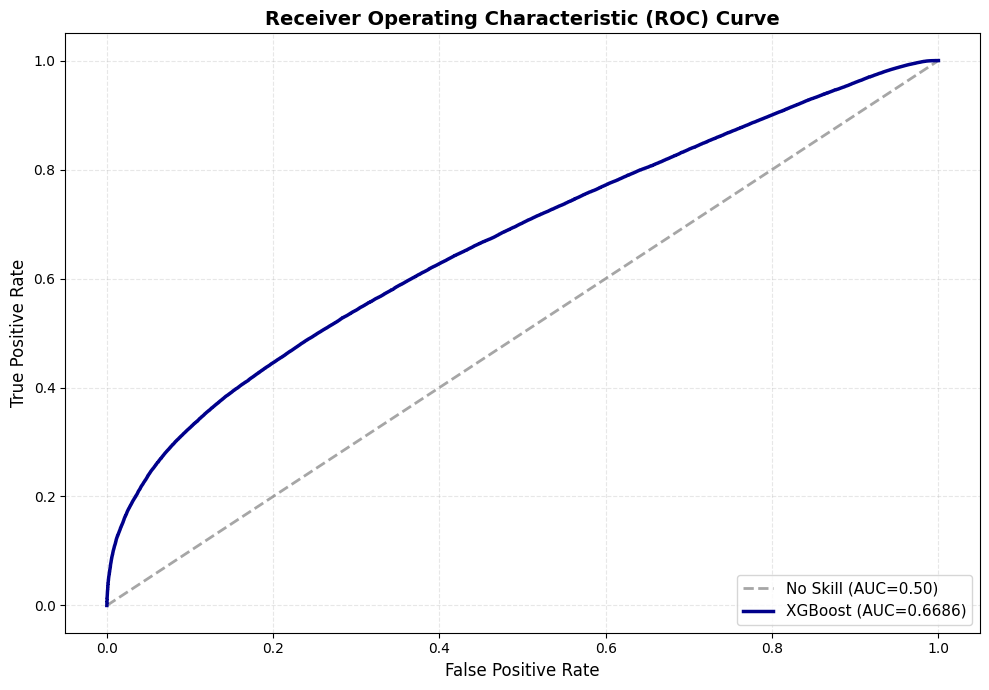

XGBoost AUC: 0.6686


In [10]:
xgb_utils.plot_roc_curves(y_val, y_prob_val)

**ROC Curve Interpretation (XGBoost Shot Make Prediction)**

The ROC curve shows that the model consistently outperforms random guessing, with an **AUC of 0.6686**, indicating moderate discriminative power. This means the model can correctly rank a randomly chosen made shot higher than a missed shot in about **66.86% of cases**. 

While not perfect, this level of performance is typical for shot outcome prediction tasks in basketball, where outcomes are inherently noisy and heavily influenced by unobserved factors such as defensive pressure and in-game decision-making.


## 8. Advanced Evaluation: xPts & Game Totals
This is the most critical part for our project ("Shot Decision Optimizer").

We calculate **Expected Points (xPts)** for every shot:
$xPts = P(\text{Make}) \times \text{Shot Value} (2 \text{ or } 3)$

Then, we check if the sum of xPts for a game correlates with the actual final score. If our model is good, the Sum of xPts should be very close to the Real Score.

#### Game-Level Validation: Sum of Expected Points (xPts) vs. Actual Final Score

This plot evaluates the model at the **game level**, which is the most critical step for the overall objective of *shot decision optimization*. Rather than assessing individual shot predictions in isolation, we aggregate the model’s outputs to test whether they produce meaningful signals at the level that ultimately matters: **final points scored in a game**.

- **X-axis (Sum of xPts – Model Prediction):**  
  For each game, we sum the expected points over all shots:
  $
  \text{xPts} = P(\text{Make}) \times \text{Shot Value} \; (2 \text{ or } 3)
  $
  This represents the total number of points the model expects the team to score, given the shot selection and the predicted make probabilities.

- **Y-axis (Actual Score):**  
  The true final score of the game.

- **Color scale (Shot Count):**  
  Each point is colored by the number of shots taken in the game, providing context on game pace and volume.



PREPARING EVALUATION DATAFRAME
Evaluation DF ready: 261,619 shots

Sample predictions:
            GAME_ID TEAM_ABBREVIATION  SHOT_VALUE  PROBABILITY_MAKE      xPts  \
1042565  0022400062               MIN           2          0.625525  1.251051   
1042559  0022400062               LAL           2          0.417410  0.834821   
1042564  0022400062               LAL           2          0.746443  1.492886   
1042563  0022400062               LAL           2          0.378232  0.756463   
1042562  0022400062               MIN           2          0.495244  0.990488   

         ACTUAL_POINTS  
1042565              0  
1042559              0  
1042564              2  
1042563              2  
1042562              0  

GAME-LEVEL EVALUATION (Sum of xPts)
Games Evaluated: 2,932
Mean Absolute Error (MAE): 9.05 points per game
Mean Squared Error (MSE):  128.17 points per game
R² Score (Correlation):    0.1644


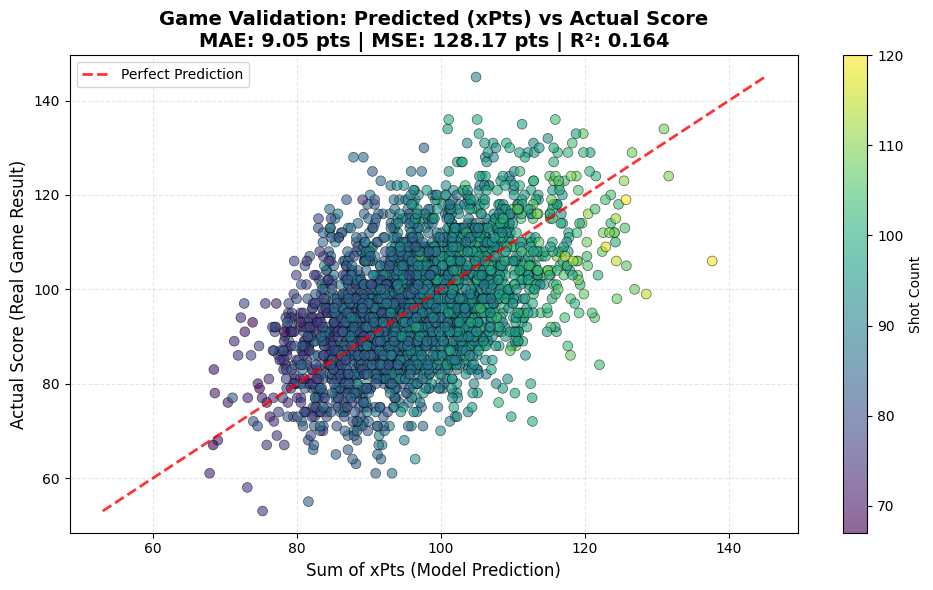

In [11]:
print("\n" + "="*60)
print("PREPARING EVALUATION DATAFRAME")
print("="*60)

# 1. Prepare DataFrame for analysis
df_eval = X_test.copy()
df_eval['PROBABILITY_MAKE'] = y_prob_test
df_eval['SHOT_MADE_FLAG'] = y_test

# 2. Restore Metadata (Game ID, Team, Shot Value)
metadata_cols = ['GAME_ID', 'TEAM_ABBREVIATION', 'SHOT_VALUE', 'GAME_EVENT_ID',
                 'SHOT_TYPE', 'LOC_Y', 'LOC_X', 'SEASON']
for col in metadata_cols:
    if col in df.columns:
        df_eval[col] = df.loc[df_eval.index, col]

# 3. Calculate xPts
df_eval = xgb_utils.calculate_xpts(df_eval)

print(f"Evaluation DF ready: {len(df_eval):,} shots")
print("\nSample predictions:")
print(df_eval[['GAME_ID', 'TEAM_ABBREVIATION', 'SHOT_VALUE',
               'PROBABILITY_MAKE', 'xPts', 'ACTUAL_POINTS']].head())

# 4. Aggregation per Game and Plotting
game_stats = xgb_utils.evaluate_game_totals(df_eval)

#### Interpretation of the results
1. **Positive but noisy relationship**  
   The upward trend indicates a clear positive correlation between summed xPts and actual score. Games with higher predicted xPts tend to result in higher final scores, suggesting that the model captures meaningful information about scoring potential. This is reflected in the non-zero \(R^2 = 0.164\).

2. **Error magnitude and realism**  
   The mean absolute error (MAE) of approximately **9 points per game** highlights that the model is not perfectly calibrated at the game level. However, given the inherent randomness in basketball (hot streaks, cold shooting nights, fouls, late-game variance, etc.), this level of error is realistic. Importantly, the model is not evaluated on a single shot, but on the aggregation of dozens to over a hundred probabilistic events per game, where variance naturally compounds.

3. **Regression toward the mean**  
   The scatter shows a tendency to underpredict very high-scoring games and overpredict very low-scoring games. This compression toward the center is typical for probabilistic models optimized on average loss functions and indicates conservative probability estimates rather than extreme predictions.

4. **Role of shot volume**  
   The color gradient reveals that games with higher shot counts tend to appear further to the right and higher up in the plot, as expected. This confirms that the xPts aggregation behaves coherently with game pace and opportunity, and that the model does not ignore volume effects.

## 9. Calibration (Reliability Diagram)

We check if the probabilities from the XGBoost model are reliable.
Similar to xGoals in soccer, we ask:
*"If the model predicts a 40% chance for a set of shots, did about 40% of them actually go in?"*

We plot this separately for **All Shots**, **2-Pointers**, and **3-Pointers** to see if the model struggles with distance shots.


CALIBRATION EVALUATION (50 Bins)


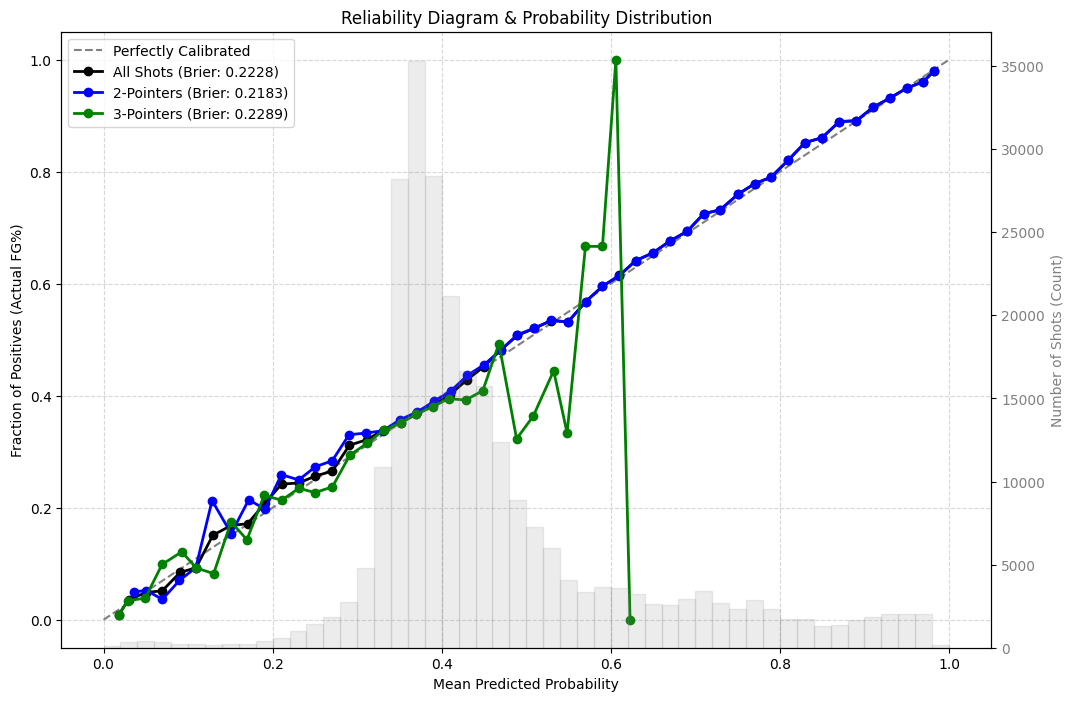


--- Detailed Bin Statistics (All Shots) ---
                Count  Avg_Pred_Prob  Actual_FG_Pct
prob_bin                                           
(-0.001, 0.02]    114       0.017999       0.008772
(0.02, 0.04]      333       0.029606       0.036036
(0.04, 0.06]      392       0.050325       0.048469
(0.06, 0.08]      328       0.069515       0.051829
(0.08, 0.1]       237       0.090526       0.084388
(0.1, 0.12]       194       0.109381       0.092784
(0.12, 0.14]      179       0.129260       0.150838
(0.14, 0.16]      208       0.150894       0.168269
(0.16, 0.18]      245       0.170419       0.171429
(0.18, 0.2]       395       0.190592       0.207595
(0.2, 0.22]       607       0.210483       0.242175
(0.22, 0.24]      991       0.230928       0.244198
(0.24, 0.26]     1419       0.250370       0.256519
(0.26, 0.28]     1824       0.270552       0.265351
(0.28, 0.3]      2753       0.290869       0.311660
(0.3, 0.32]      4800       0.311084       0.321250
(0.32, 0.34]    108

In [12]:
xgb_utils.evaluate_calibration(df_eval, n_bins=50)

### Reliability Diagram (Calibration Insight)

This reliability diagram highlights both the strengths and the inherent limitations of probabilistic shot modeling in basketball.

- **Overall behavior:**  
  The aggregate calibration curve tracks the diagonal reasonably well, indicating that the model’s predicted probabilities are directionally aligned with observed make rates. This suggests that, in expectation, the model assigns higher probabilities to shots that are indeed converted more frequently.

- **Lack of smoothness and sample size effects:**  
  The irregular and jagged shape of the curves most notably for 3-point attempts, is not primarily a modeling failure but a consequence of limited sample sizes in higher-probability bins. Truly high-probability shots, especially from three-point range, are rare in real games, making empirical calibration in these regions inherently noisy.

- **Basketball-specific uncertainty:**  
  Unlike many classification tasks, basketball shots are rarely “guaranteed.” Even shots that appear open or well selected remain influenced by defender recovery, shooter fatigue, timing, and random variation. This intrinsic uncertainty prevents the calibration curve from forming a perfectly smooth or monotonic relationship.


## 10. Shot Quality Insights

We visualize the expected points (xPts) to understand how the model values shot locations.

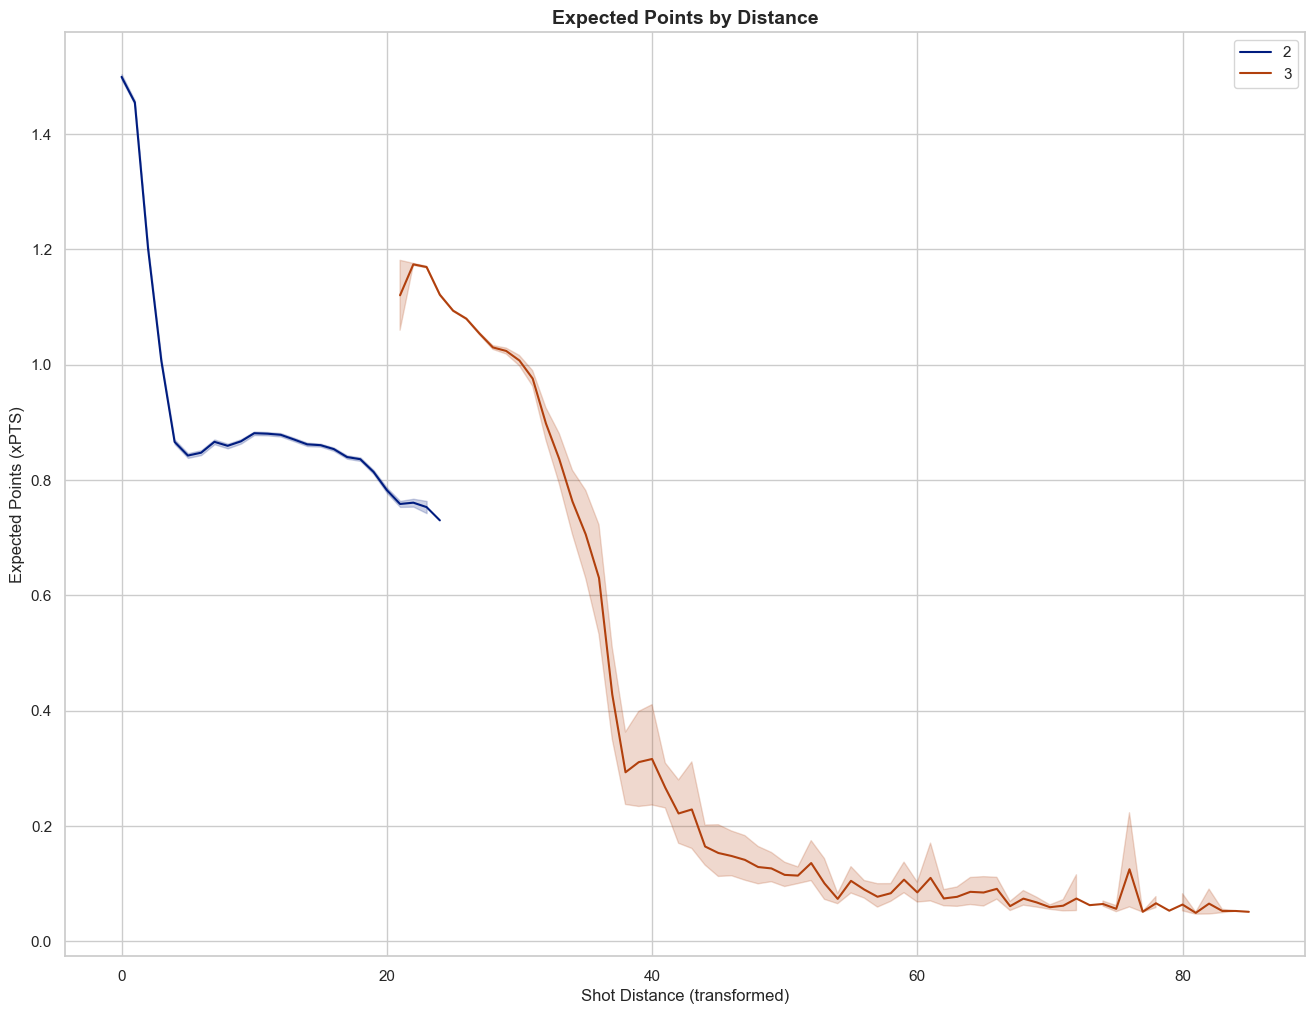

In [13]:
def plot_expected_points_analysis(df):
    # Berechnung der Expected Points (xPTS)
    df['xPTS'] = df['PROBABILITY_MAKE'] * df['SHOT_VALUE']

    sns.set_theme(style="whitegrid")
    fig = plt.subplots(1, 1, figsize=(16, 12))

    sns.lineplot(data=df, x='SHOT_DISTANCE', y='xPTS', hue='SHOT_VALUE', palette='dark')

    plt.title("Expected Points by Distance", fontsize=14, fontweight='bold')
    plt.xlabel("Shot Distance (transformed)")
    plt.ylabel("Expected Points (xPTS)")
    plt.legend()
    plt.show()

plot_expected_points_analysis(df_eval)

**Interpretation**

Expected points are highest near the basket due to very high finishing efficiency and decline steadily as distance increases. Three-point shots are efficient at standard three-point range but lose expected value rapidly as distance extends beyond it. Overall, the plot reinforces that optimal shot selection favors close-range attempts and regular three-pointers over long-distance shots.


### Expected Points by Shot Distance

This plot illustrates how **expected points (xPts)** vary as a function of shot distance, separately for **2-point shots** and **3-point shots**, thereby directly connecting the probabilistic model outputs to decision-making incentives on the court.

- **Rim dominance for 2-point attempts:**  
  At very short distances, 2-point shots yield the highest expected value, reflecting both high make probabilities and guaranteed point value. The steep drop immediately after the rim highlights how quickly finishing efficiency declines once shots move out of the restricted area, even before reaching typical mid-range distances.

- **Mid-range inefficiency:**  
  As distance increases within the 2-point range, expected points steadily decrease and stabilize at a relatively low level. This region corresponds to traditional mid range attempts, where neither shot value nor make probability is sufficiently high to generate strong expected returns. The flat, low slope reinforces the insight, that mid range shots are generally suboptimal from an expected value perspective.

- **Three-point “efficiency window”:**  
  At the shortest three-point distances, expected points briefly exceed those of most mid range twos. This reflects the compensation provided by the additional point, even though make probabilities are lower than for close range shots. This window explains why corner and short above the break threes are strategically valuable despite their distance.

- **Rapid decay at extended range:**  
  Beyond this initial three point region, expected points decline sharply as distance increases. The steep downward slope and widening uncertainty band indicate that long range threes are both low probability and high variance events. Occasional spikes reflect small sample noise rather than sustainable shot quality.

- **Decision-making implication:**  
  The plot makes clear that not all distance is equal: optimal shot selection clusters around the rim and the most efficient three-point zones, while both long mid range twos and deep threes offer poor expected returns. This reinforces the central premise of shot decision optimization; maximizing scoring is achieved not by shot volume alone, but by systematically favoring distance zones with superior expected value over many possessions.

---

## 11. Conclusion & Final Report: The Math Behind the Shot

We started this project with a simple question: **"Can we quantify the quality of a basketball shot?"**

By moving from raw shot charts to a probabilistic **Expected Points (xPts)** model, we have transformed binary outcomes (Made/Missed) into a continuous spectrum of shot quality.

#### **1. Model Performance Overview**
Our XGBoost model demonstrates a solid ability to distinguish efficient shots from inefficient ones, acting as a "conservative" optimizer that prioritizes high-quality looks.
*   **Log Loss (0.6326):** Indicates stable probability estimates.
*   **ROC-AUC (0.6686):** Shows moderate but meaningful discriminative power in ranking shot quality.
*   **Accuracy (63.26%):** A strong baseline given the inherent variance.

#### **2. Classification Dynamics (Precision vs. Recall)**
The classification report reveals the model's distinct behavior:

*   **Class 0 (Misses):** High Recall (**0.84**) means the model is excellent at identifying "bad shots" that will likely miss.
*   **Class 1 (Makes):** High Precision (**0.69**) but lower Recall (**0.40**).
*   *Interpretation:* The model is "picky." It only predicts a shot will go in if the conditions are very favorable. It essentially says, "I'm not sure about that contested jumper, but I am confident about this open dunk."

For a decision optimizer, this is a **feature, not a bug**. We want to recommend shots that are reliably good, not shots that just happened to go in due to luck or exceptional individual brilliance.

 #### **3. Game-Level Validation (The "xPts" Test)**
 When we aggregate our individual shot predictions to the game level, we see the real-world value of the model:

 *   **Correlation ($R^2$ = 0.164):** There is a positive link between the quality of shots taken (sum of xPts) and the final score.
 *   **Mean Absolute Error (MAE = 9.05 pts):** On average, the model's expected score is within ~9 points of the actual score. Considering the pace of modern NBA games (scoring 110+ points) and the variance involved, this confirms that **shot quality is a significant driver of game outcomes**, even if it doesn't explain everything (turnovers, free throws, and defense also matter).

---
### **Final Verdict**
We have successfully established a **robust quantitative baseline** for shot evaluation. While the model does not capture every nuance, its strong calibration confirms that it effectively isolates the *structural quality* of a shot from random noise. 

This model serves as a reliable foundation for our **Shot Decision Optimizer**, allowing us to shift the conversation from "Did it go in?" to "Was it the right decision?" based on data rather than just intuition.
